# 📗 Notebook 2: Performance Analysis & Sensitivity

**Mục tiêu:** *"Seed nào tốt nhất? Tham số nào tạo ra ν âm mạnh nhất?"*

Sử dụng cleaned dataset từ Notebook 1 (hoặc trực tiếp `_all_summaries_parallel.json`), tập trung vào thống kê và tương quan.

### Các phân tích chính:
1. So sánh hiệu suất Top-level — Boxplot/Violinplot nu12 theo seed
2. Heatmap tương quan Spearman giữa tất cả tham số và metrics
3. Pareto Front: VolFrac vs nu12 — xác định "vùng vàng"
4. Phân tích rmin vs nu12 — tìm ngưỡng rmin tối đa
5. Đánh giá ảnh hưởng của các tham số

In [8]:
# ── Setup & Imports ──
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sys.path.insert(0, str(Path.cwd() / "notebooks"))
import utils

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Load cleaned data ──
data_path = Path.cwd() / "notebooks" / "cleaned_dataset.parquet"
if data_path.exists():
    df = pd.read_parquet(data_path)
    print(f"Loaded cleaned dataset: {len(df)} rows from {data_path}")
else:
    print("cleaned_dataset.parquet not found — loading from raw Phase 1 data...")
    df = utils.load_all_samples(drop_void=False)
    print(f"Loaded raw dataset: {len(df)} rows")

# Filter to valid non-void samples for most analyses
df_valid = df[df["nu_valid_flag"] & ~df["void_flag"]].copy()
print(f"Valid non-void samples: {len(df_valid)}")

cleaned_dataset.parquet not found — loading from raw Phase 1 data...
Loaded raw dataset: 300 rows
Valid non-void samples: 297


---
## 1. So sánh hiệu suất Top-level

Seed nào có median nu12 thấp nhất (âm nhất)?

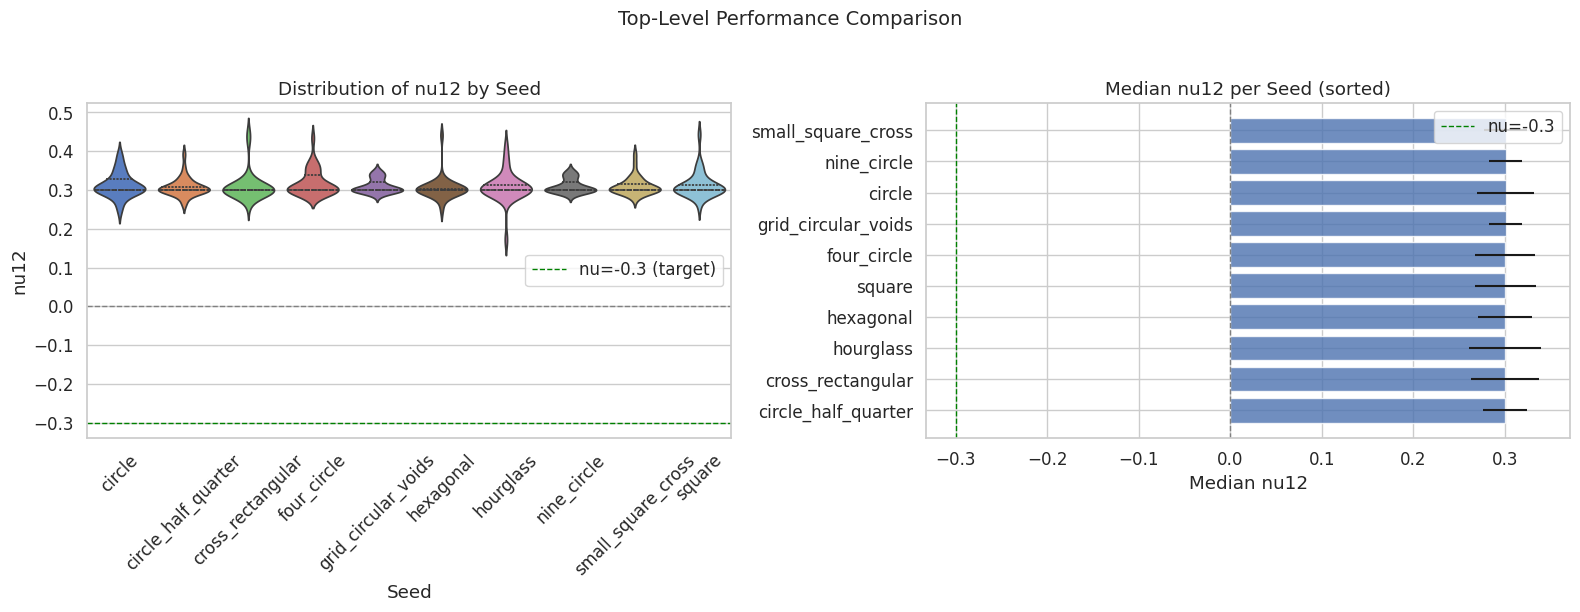


Seed statistics (sorted by median nu12):


,median,mean,std,count
seed,,,,
circle_half_quarter,0.3000,0.3077,0.0237,30
cross_rectangular,0.3000,0.3098,0.0370,30
hourglass,0.3000,0.3089,0.0394,29
hexagonal,0.3000,0.3046,0.0294,30
square,0.3001,0.3130,0.0333,30
four_circle,0.3002,0.3190,0.0330,30
grid_circular_voids,0.3005,0.3107,0.0178,29
circle,0.3005,0.3128,0.0313,30
nine_circle,0.3005,0.3107,0.0178,29


In [9]:
# ── Violinplot + Boxplot nu12 by seed ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.violinplot(data=df_valid, x="seed", y="final_nu12", ax=ax, palette="muted", inner="quartile")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axhline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3 (target)")
ax.set_xlabel("Seed")
ax.set_ylabel("nu12")
ax.set_title("Distribution of nu12 by Seed")
ax.tick_params(axis="x", rotation=45)
ax.legend()

ax = axes[1]
seed_stats = df_valid.groupby("seed")["final_nu12"].agg(["median", "mean", "std", "count"]).round(4)
seed_stats_sorted = seed_stats.sort_values("median")
ax.barh(range(len(seed_stats_sorted)), seed_stats_sorted["median"].values, 
        xerr=seed_stats_sorted["std"].values, color="#4c72b0", alpha=0.8)
ax.set_yticks(range(len(seed_stats_sorted)))
ax.set_yticklabels(seed_stats_sorted.index)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.axvline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3")
ax.set_xlabel("Median nu12")
ax.set_title("Median nu12 per Seed (sorted)")
ax.legend()

fig.suptitle("Top-Level Performance Comparison", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Show stats table
print("\nSeed statistics (sorted by median nu12):")
display(seed_stats_sorted)

---
## 2. Heatmap tương quan Spearman

Xác định mối tương quan giữa tất cả tham số và metrics.

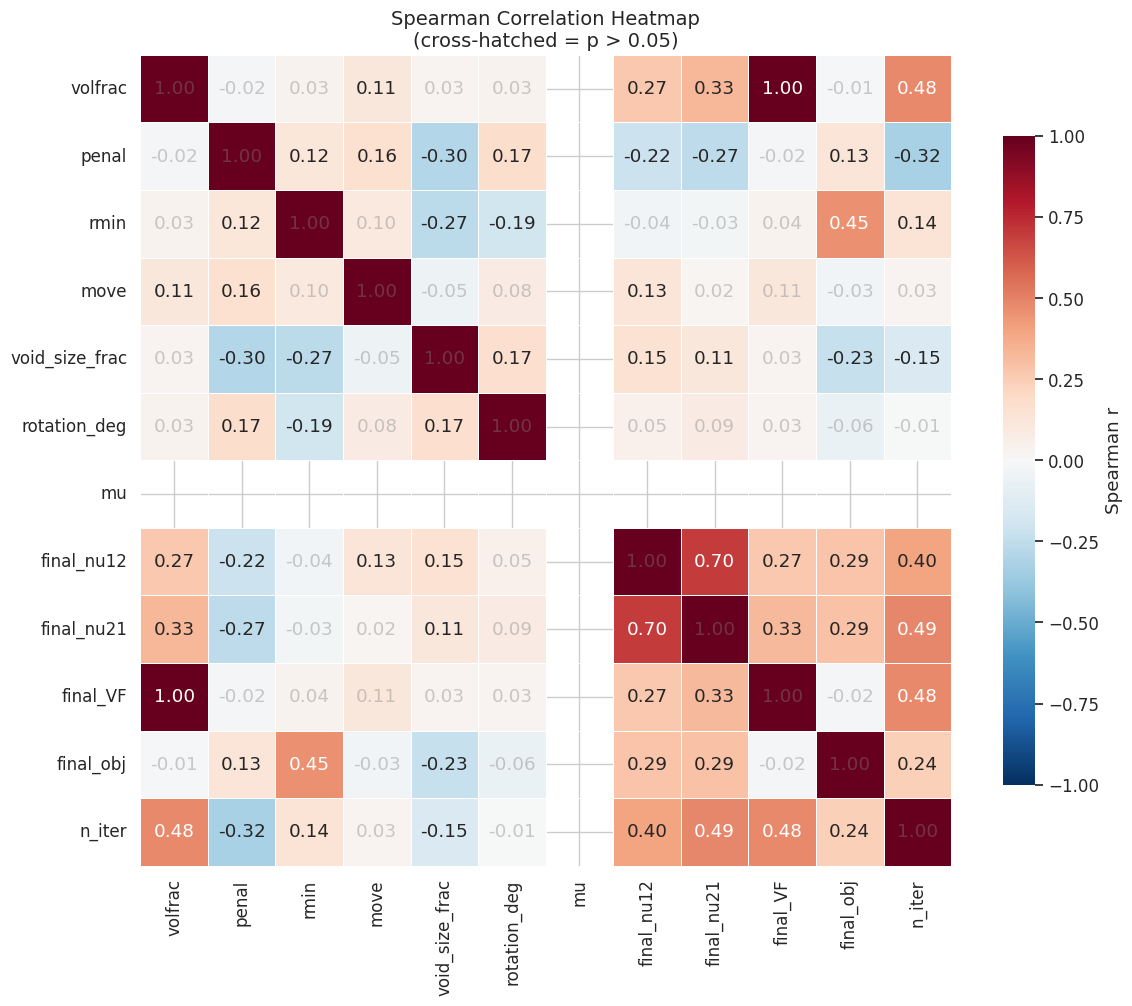


--- Spearman correlation with nu12 ---
  penal          : r = -0.2162  (p = 0.0002) ***
  rmin           : r = -0.0351  (p = 0.5468) 
  rotation_deg   : r = +0.0540  (p = 0.3540) 
  move           : r = +0.1288  (p = 0.0264) *
  void_size_frac : r = +0.1547  (p = 0.0076) **
  final_VF       : r = +0.2677  (p = 0.0000) ***
  volfrac        : r = +0.2709  (p = 0.0000) ***
  final_obj      : r = +0.2866  (p = 0.0000) ***
  n_iter         : r = +0.4013  (p = 0.0000) ***
  mu             : r = +nan  (p = nan) 


In [10]:
# ── Correlation analysis ──
param_cols = ["volfrac", "penal", "rmin", "move", "void_size_frac", "rotation_deg", "mu"]
metric_cols = ["final_nu12", "final_nu21", "final_VF", "final_obj", "n_iter"]
all_cols = param_cols + metric_cols

df_corr = df_valid[all_cols].dropna()

# Spearman correlation matrix
corr_matrix = df_corr.corr(method="spearman")

# P-value matrix
pval_matrix = pd.DataFrame(np.ones_like(corr_matrix), index=corr_matrix.index, columns=corr_matrix.columns)
for c1 in corr_matrix.columns:
    for c2 in corr_matrix.index:
        if c1 != c2:
            r, p = spearmanr(df_corr[c1], df_corr[c2])
            pval_matrix.loc[c2, c1] = p

# Mask for significance
mask_sig = pval_matrix > 0.05

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            mask=mask_sig, cbar_kws={"shrink": 0.8, "label": "Spearman r"})

# Overlay non-significant cells with hatching
if mask_sig.any().any():
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
                mask=~mask_sig, 
                cbar=False, annot_kws={"color": "gray", "alpha": 0.4})

ax.set_title("Spearman Correlation Heatmap\n(cross-hatched = p > 0.05)", fontsize=14)
fig.tight_layout()
plt.show()

# Print key findings: params vs nu12
print("\n--- Spearman correlation with nu12 ---")
nu_corr = corr_matrix["final_nu12"].drop(["final_nu12", "final_nu21"]).sort_values()
for param, r in nu_corr.items():
    p = pval_matrix.loc[param, "final_nu12"]
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:15s}: r = {r:+.4f}  (p = {p:.4f}) {stars}")

---
## 3. Pareto Front: VolFrac vs nu12

Xác định vùng "vàng" với nu12 < -0.3 đồng thời Volume Fraction hợp lý.

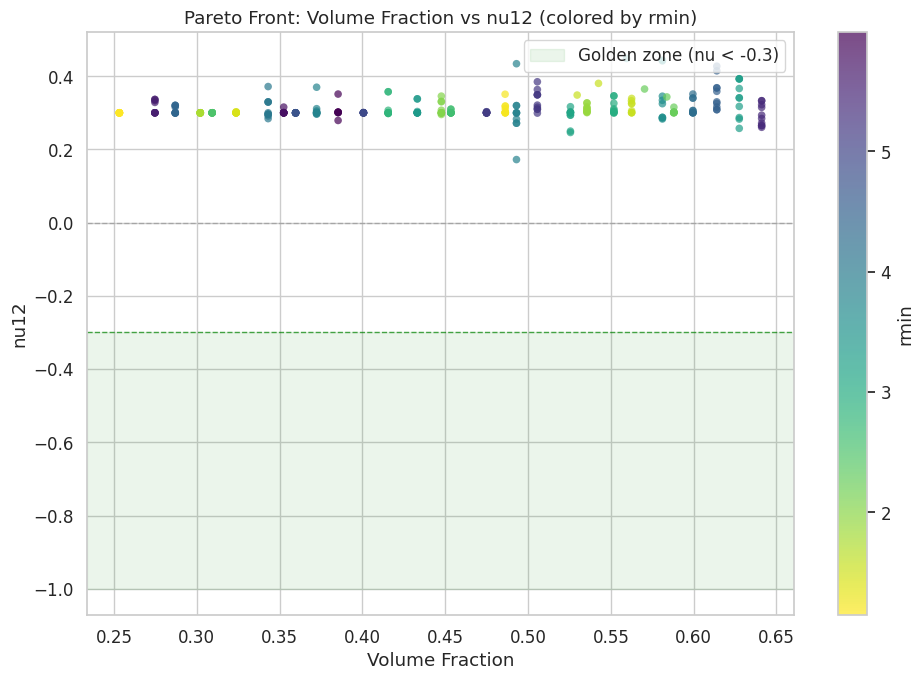

Samples in golden zone (nu12 < -0.3): 0 (0.0%)


In [11]:
# ── Scatter: Volume Fraction vs nu12 ──
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(df_valid["final_VF"], df_valid["final_nu12"], 
                c=df_valid["rmin"], cmap="viridis_r", alpha=0.7, s=30, edgecolors="none")
cbar = plt.colorbar(sc, ax=ax, label="rmin")

# Highlight golden zone
ax.axhspan(-1, -0.3, xmin=0, xmax=1, alpha=0.08, color="green", label="Golden zone (nu < -0.3)")
ax.axhline(-0.3, color="green", ls="--", lw=1, alpha=0.7)
ax.axhline(0, color="gray", ls="--", lw=1, alpha=0.5)

ax.set_xlabel("Volume Fraction")
ax.set_ylabel("nu12")
ax.set_title("Pareto Front: Volume Fraction vs nu12 (colored by rmin)")
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

# Count golden zone samples
golden = df_valid[df_valid["final_nu12"] < -0.3]
print(f"Samples in golden zone (nu12 < -0.3): {len(golden)} ({len(golden)/len(df_valid)*100:.1f}%)")
if len(golden) > 0:
    print(f"  Their rmin range: {golden['rmin'].min():.2f} – {golden['rmin'].max():.2f}")
    print(f"  Their volfrac range: {golden['volfrac'].min():.4f} – {golden['volfrac'].max():.4f}")
    print(f"  Their void_size_frac range: {golden['void_size_frac'].min():.4f} – {golden['void_size_frac'].max():.4f}")

---
## 4. Phân tích rmin vs nu12

Tìm ngưỡng rmin tối đa — nếu rmin quá lớn, tính auxetic biến mất.

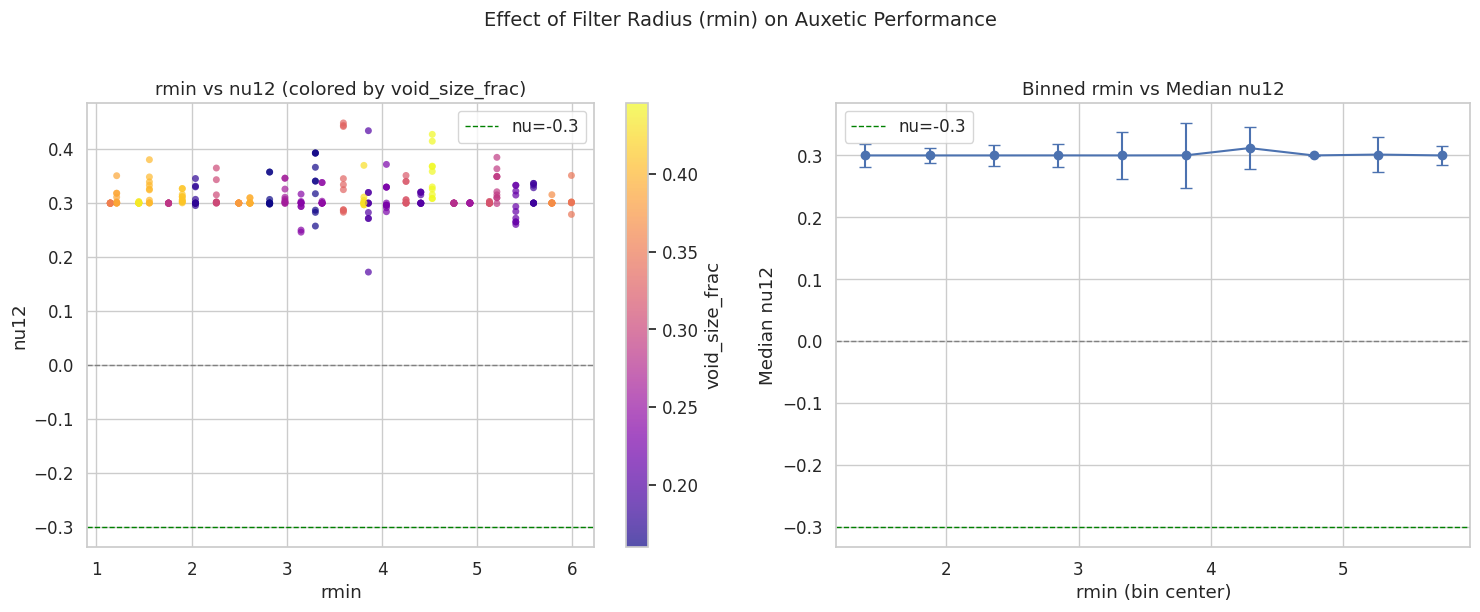

--- rmin Threshold Analysis ---
Samples with rmin > 3: 177
  Among them, auxetic (nu12 < 0): 0 (0.0%)
Max rmin for nu12 < -0.3: 0.00


In [12]:
# ── rmin vs nu12 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.scatter(df_valid["rmin"], df_valid["final_nu12"], 
           c=df_valid["void_size_frac"], cmap="plasma", alpha=0.7, s=25, edgecolors="none")
cbar = plt.colorbar(ax.collections[0], ax=ax, label="void_size_frac")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axhline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3")
ax.set_xlabel("rmin")
ax.set_ylabel("nu12")
ax.set_title("rmin vs nu12 (colored by void_size_frac)")
ax.legend()

# Determine max rmin threshold
ax = axes[1]
# Bin rmin and compute median nu12 per bin
rmin_bins = pd.cut(df_valid["rmin"], bins=10)
binned = df_valid.groupby(rmin_bins, observed=True)["final_nu12"].agg(["median", "std", "count"])
bin_centers = [interval.mid for interval in binned.index]
ax.errorbar(bin_centers, binned["median"], yerr=binned["std"], 
            marker="o", capsize=4, color="#4c72b0", linestyle="-")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axhline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3")
ax.set_xlabel("rmin (bin center)")
ax.set_ylabel("Median nu12")
ax.set_title("Binned rmin vs Median nu12")
ax.legend()

fig.suptitle("Effect of Filter Radius (rmin) on Auxetic Performance", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Find threshold
high_rmin = df_valid[df_valid["rmin"] > 3].copy()
auxetic_high_rmin = high_rmin[high_rmin["final_nu12"] < 0]
print(f"--- rmin Threshold Analysis ---")
print(f"Samples with rmin > 3: {len(high_rmin)}")
print(f"  Among them, auxetic (nu12 < 0): {len(auxetic_high_rmin)} ({len(auxetic_high_rmin)/len(high_rmin)*100:.1f}%)")

# Find max rmin that still produces nu12 < -0.3
golden_rmin_max = golden["rmin"].max() if len(golden) > 0 else 0
print(f"Max rmin for nu12 < -0.3: {golden_rmin_max:.2f}")

---
## 5. Ảnh hưởng của các tham số chính

Phân tích chi tiết `void_size_frac`, `volfrac`, `penal` ảnh hưởng đến nu12.

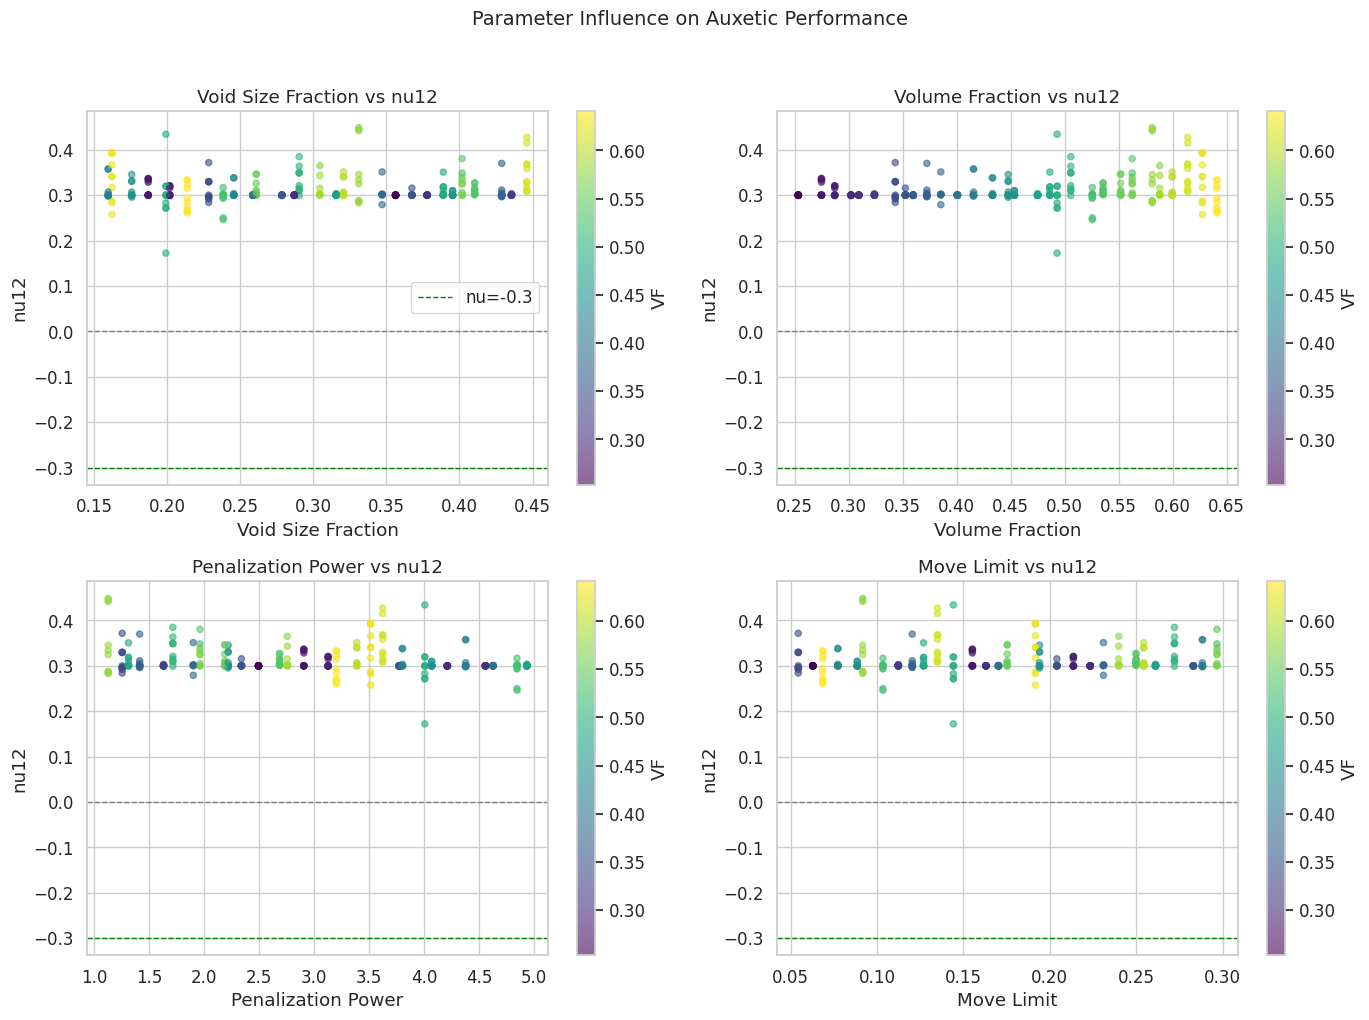

In [13]:
# ── Multi-panel parameter influence ──
key_params = [("void_size_frac", "Void Size Fraction"),
              ("volfrac", "Volume Fraction"),
              ("penal", "Penalization Power"),
              ("move", "Move Limit")]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, (param, label) in enumerate(key_params):
    ax = axes_flat[i]
    sc = ax.scatter(df_valid[param], df_valid["final_nu12"],
                    c=df_valid["final_VF"], cmap="viridis", alpha=0.6, s=20)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.axhline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3")
    ax.set_xlabel(label)
    ax.set_ylabel("nu12")
    ax.set_title(f"{label} vs nu12")
    if i == 0:
        ax.legend()
    plt.colorbar(sc, ax=ax, label="VF")

fig.suptitle("Parameter Influence on Auxetic Performance", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 📋 Tổng kết Notebook 2

In [14]:
# ── Final summary ──
top3_seeds = seed_stats_sorted.head(3).index.tolist()
best_seed = seed_stats_sorted.index[0]

# Find most influential params (abs correlation with nu12)
param_influence = nu_corr.abs().sort_values(ascending=False)

print("=" * 60)
print("  NOTEBOOK 2 — PERFORMANCE ANALYSIS & SENSITIVITY")
print("=" * 60)
print(f"  • Best seed (lowest median nu12):  {best_seed}")
print(f"  • Top 3 seeds:                      {', '.join(top3_seeds)}")
print(f"  • Samples in golden zone (nu<-0.3): {len(golden)}")
print(f"  • Max rmin for nu < -0.3:           {golden_rmin_max:.2f}")
print(f"\n  Most influential parameters on nu12:")
for param, _ in param_influence.head(3).items():
    r = nu_corr[param]
    print(f"    {param:20s}: r = {r:+.4f}")
print("=" * 60)
print("\n✅ Results ready for Notebook 3.")

  NOTEBOOK 2 — PERFORMANCE ANALYSIS & SENSITIVITY
  • Best seed (lowest median nu12):  circle_half_quarter
  • Top 3 seeds:                      circle_half_quarter, cross_rectangular, hourglass
  • Samples in golden zone (nu<-0.3): 0
  • Max rmin for nu < -0.3:           0.00

  Most influential parameters on nu12:
    n_iter              : r = +0.4013
    final_obj           : r = +0.2866
    volfrac             : r = +0.2709

✅ Results ready for Notebook 3.
